<h1>Loan Default data preprocessing</h1>

<h2>Importing dataset</h2>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn  as sns

In [2]:
df = pd.read_csv("../data/Loan_default.csv")
df.head()
df_visualize = df.copy()
df_standardscaler = df.copy()
df_minmaxscale = df.copy()

<h2>Removing LoadID</h2>

In [3]:
df.drop(columns='LoanID',inplace=True)

In [4]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


<h2>1. Understand the data (done in EDA)</h2>

<h2>2. Handling Missing Values</h2>

<h3>Number of missing values per column</h3>

In [5]:
df.isna().sum()

Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

<h3>Number of missing values through out the dataset</h3>

In [6]:
print(f"Number of missing values through out the dataset : {df.isna().sum().sum()}")

Number of missing values through out the dataset : 0


<h2>3. Handling Duplicate values</h2>

In [7]:
print(f'Number of duplicate records through out the dataset : {df.duplicated().sum()}')

Number of duplicate records through out the dataset : 0


<h2>4. Fix data types</h2>

<h3>Data-Type of each columns</h3>

In [8]:
df.dtypes

Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

<h2>5. Handle outliers</h2>

<h3>Finding outliers though visulization</h3>

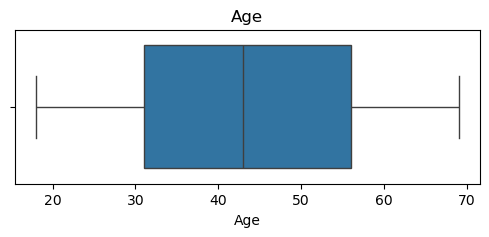

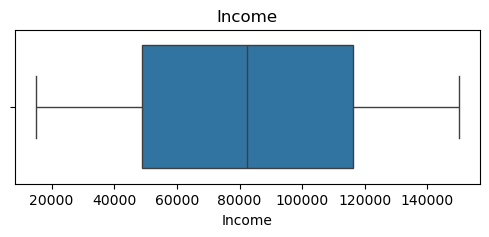

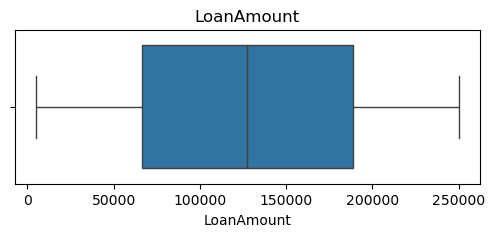

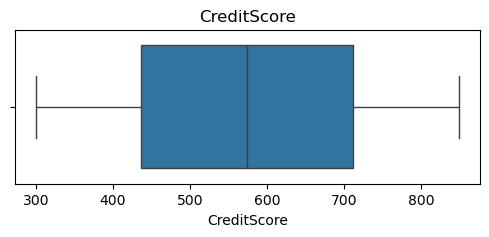

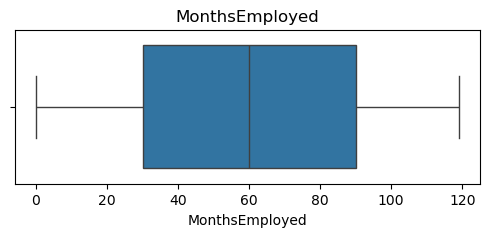

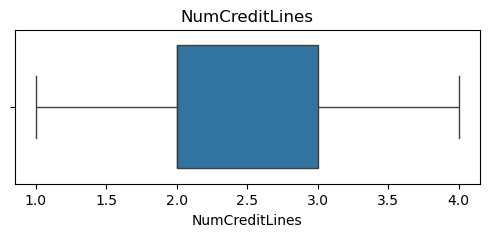

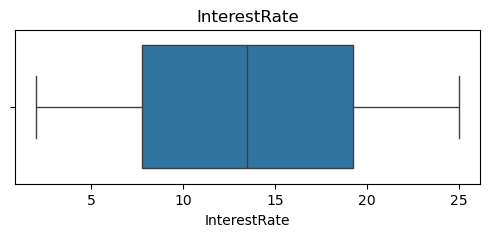

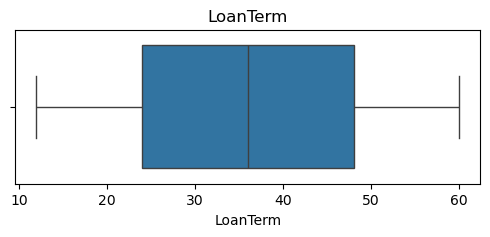

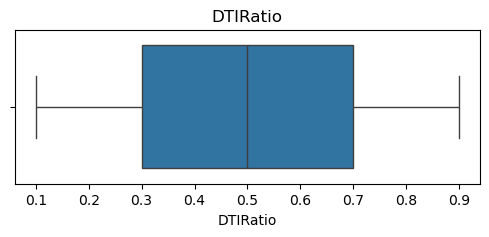

In [9]:
numerical_cols = [
    'Age',
    'Income',
    'LoanAmount',
    'CreditScore',
    'MonthsEmployed',
    'NumCreditLines',
    'InterestRate',
    'LoanTerm',
    'DTIRatio'
]

for col in numerical_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


In [10]:
print("Outliers count for each numeric-data column")

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {count}")

Outliers count for each numeric-data column
Age: 0
Income: 0
LoanAmount: 0
CreditScore: 0
MonthsEmployed: 0
NumCreditLines: 0
InterestRate: 0
LoanTerm: 0
DTIRatio: 0


<h2>6. Encode categories</h2>

<h3>One-Hot Encoding</h3>

In [11]:
df = pd.get_dummies(df,columns=['Education','EmploymentType','MaritalStatus','LoanPurpose'])
df.replace(True,1,inplace=True)
df.replace(False,0,inplace=True)

C:\Users\Aadit\AppData\Local\Temp\ipykernel_6752\3647081076.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(False,0,inplace=True)


<h3>Label Encoding</h3>

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['HasMortgage'] = le.fit_transform(df['HasMortgage'])

df['HasCoSigner'] = le.fit_transform(df['HasCoSigner'])

df['HasDependents'] = le.fit_transform(df['HasDependents'])


In [13]:
# from sklearn.preprocessing import LabelEncoder

# for col in ['HasMortgage', 'HasCoSigner', 'HasDependents']:
#     le = LabelEncoder()
#     df[col] = le.fit_transform(df[col])

#     mapping = dict(zip(le.classes_, le.transform(le.classes_)))
#     print(f"{col}: {mapping}")
# HasMortgage: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
# HasCoSigner: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
# HasDependents: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}    

In [14]:
df.head(5)

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,...,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Auto,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,56,85994,50587,520,80,4,15.23,36,0.44,1,...,0,0,1,0,0,0,0,0,0,1
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,0,0,0,1,0,0,0,0,0,1
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,0,1,1,0,0,1,0,0,0,0
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,0,0,0,1,0,0,1,0,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,0,1,1,0,0,1,0,0,0,0


<h2>7. Scale numbers</h2>

In [15]:
nummeric_columns = ['Age','Income','LoanAmount','CreditScore','MonthsEmployed',
                    'NumCreditLines','InterestRate','LoanTerm','DTIRatio']

<h3>Standardization (Z-score Scaling)</h3>

In [16]:
# Centers the data around 0
# Mean becomes 0
# Standard deviation becomes 1
# Values above the mean become positive
# Values below the mean become negative

from sklearn.preprocessing import StandardScaler

standardscaler = StandardScaler()

df_standardscaler = standardscaler.fit_transform(df[numerical_cols])

pd.DataFrame(df_standardscaler,columns=numerical_cols)


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio
0,0.833990,0.089693,-1.086833,-0.341492,0.590533,1.341937,0.261771,-0.001526,-0.260753
1,1.701221,-0.823021,-0.044309,-0.731666,-1.285731,-1.343791,-1.308350,1.412793,0.778585
2,0.166888,0.043854,0.022715,-0.775718,-0.968209,0.446694,1.156831,-0.708685,-0.823728
3,-0.767053,-1.303452,-1.168538,1.061875,-1.718715,0.446694,-0.967805,-0.708685,-1.170174
4,1.100830,-1.592855,-1.671921,0.369631,-1.487790,1.341937,-1.052188,0.705634,0.995114
...,...,...,...,...,...,...,...,...,...
255342,-1.634285,-1.142632,1.173101,-0.209337,1.427636,1.341937,0.093006,-1.415845,1.514783
255343,-0.767053,-0.783984,0.879724,-0.398130,-1.314597,-0.448549,-0.292744,-0.708685,-1.256785
255344,0.833990,0.059562,1.139391,0.143078,0.301877,0.446694,-1.236022,1.412793,-0.000918
255345,-0.099952,0.066979,-0.945840,1.477221,-0.564091,-1.343791,1.116146,0.705634,-0.260753


<h3>Normalization (Min-Max Scaling)</h3>

In [17]:
# Scales all values to the range [0, 1]
# Minimum value becomes 0
# Maximum value becomes 1


from sklearn.preprocessing import MinMaxScaler

minmaxscaler = MinMaxScaler()

df_minmaxscale = minmaxscaler.fit_transform(df[numerical_cols])

pd.DataFrame(df_minmaxscale,columns=numerical_cols)


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio
0,0.745098,0.525885,0.186070,0.400729,0.672269,1.000000,0.575217,0.50,0.4250
1,1.000000,0.262461,0.487512,0.287796,0.126050,0.000000,0.122174,1.00,0.7250
2,0.549020,0.512656,0.506892,0.275046,0.218487,0.666667,0.833478,0.25,0.2625
3,0.274510,0.123801,0.162446,0.806922,0.000000,0.666667,0.220435,0.25,0.1625
4,0.823529,0.040274,0.016894,0.606557,0.067227,1.000000,0.196087,0.75,0.7875
...,...,...,...,...,...,...,...,...,...
255342,0.019608,0.170216,0.839522,0.438980,0.915966,1.000000,0.526522,0.00,0.9375
255343,0.274510,0.273728,0.754693,0.384335,0.117647,0.333333,0.415217,0.25,0.1375
255344,0.745098,0.517189,0.829775,0.540984,0.588235,0.666667,0.143043,1.00,0.5000
255345,0.470588,0.519330,0.226838,0.927140,0.336134,0.000000,0.821739,0.75,0.4250


<h2>8. Visualize</h2>

Text(0, 0.5, 'Number of Records')

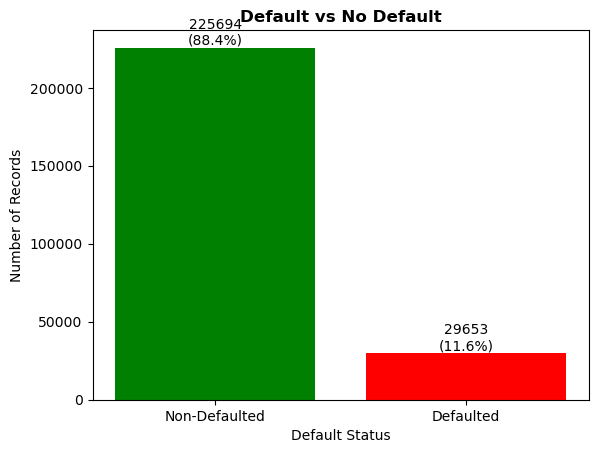

In [18]:
Counts = df_visualize['Default'].value_counts()
total = df_visualize['Default'].count()

labels = ['Non-Defaulted','Defaulted']

bars = plt.bar(labels, Counts.values, color=['g','r'])

for bar in bars:
    height = bar.get_height()
    percentage = height / total * 100

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height}\n({percentage:.1f}%)',
        ha='center',
        va='bottom'
    )

plt.title('Default vs No Default', fontweight='bold')
plt.xlabel("Default Status")
plt.ylabel("Number of Records")




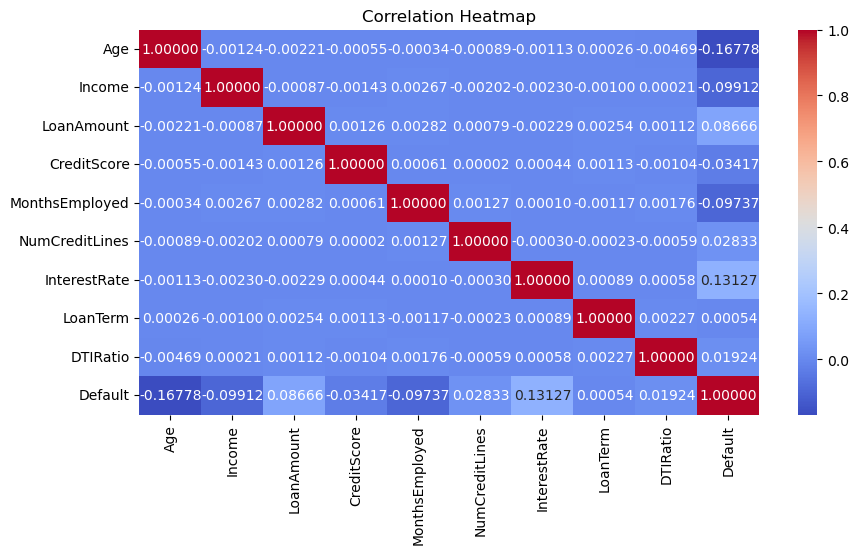

In [19]:
plt.figure(figsize=(10,5))
sns.heatmap(df_visualize.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.5f')

plt.title("Correlation Heatmap")
plt.show()

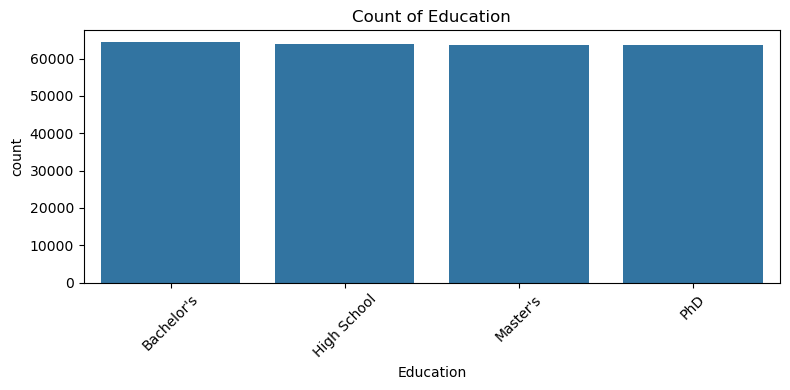

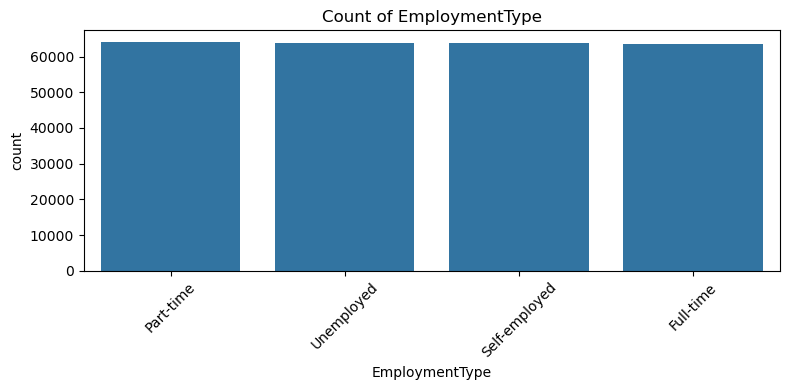

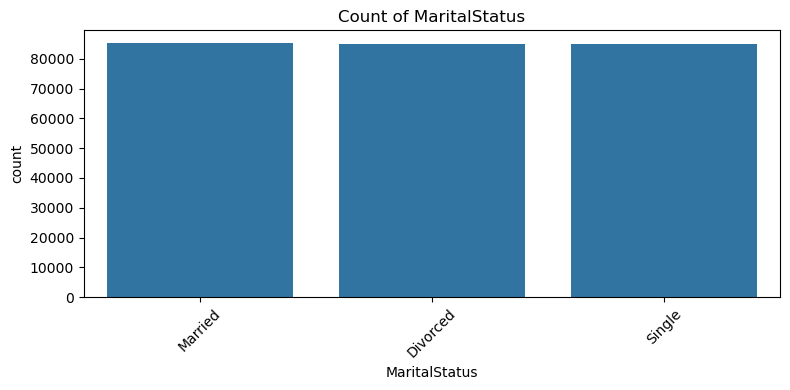

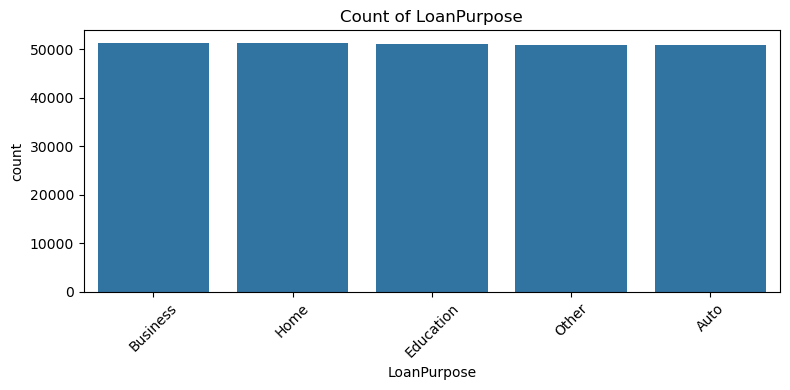

In [20]:
cols = ['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose']

for col in cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_visualize, x=col, order=df_visualize[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f'Count of {col}')
    plt.tight_layout()
    plt.show()


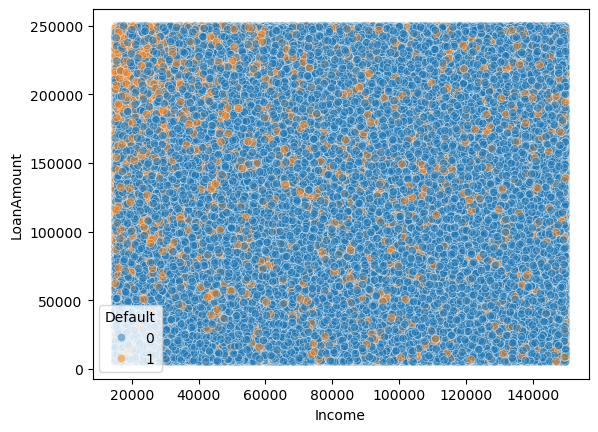

In [21]:
sns.scatterplot(data=df,
                x='Income',
                y='LoanAmount',
                hue='Default',
                alpha=0.5)

plt.show()